In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [2]:
file = "Latihan UV Vis 21 Juli 2022.xlsx"

df = pd.read_excel(file)

print("Ukuran Awal :", df.shape)

df.head()

Ukuran Awal : (5, 186)


,No.,Type,Name,Date/Time,Note,200,205,210,215,220,...,1055,1060,1065,1070,1075,1080,1085,1090,1095,1100
0,1,Sample,UV 1264,2022-07-20 15:02:00,NaN,4.8830,4.6093,4.3077,3.9963,3.6904,...,0.2748,0.2741,0.2733,0.2726,0.2719,0.2711,0.2702,0.2692,0.2681,0.2669
1,2,Sample,UV 1265,2022-07-20 15:13:00,NaN,6.0962,5.5991,5.0360,4.4370,3.8294,...,0.1760,0.1747,0.1733,0.1721,0.1708,0.1695,0.1683,0.1670,0.1657,0.1644
2,3,Sample,UV 1266,2022-07-20 15:11:00,NaN,5.2437,5.1079,4.9146,4.6848,4.4369,...,0.1762,0.1748,0.1735,0.1722,0.1709,0.1697,0.1685,0.1673,0.1661,0.1649
3,4,Sample,UV 1267,2022-07-20 15:19:00,NaN,1.4835,1.4050,1.3324,1.2672,1.2108,...,0.1498,0.1481,0.1465,0.1450,0.1434,0.1420,0.1405,0.1392,0.1378,0.1365
4,5,Sample,UV 1268,2022-07-20 15:22:00,NaN,0.8686,1.0941,1.2534,1.3570,1.4148,...,0.3507,0.3501,0.3495,0.3489,0.3483,0.3476,0.3469,0.3461,0.3452,0.3442


In [3]:
drop_cols = [
    'No.',
    'Type',
    'Date/Time',
    'Note'
]

for col in drop_cols:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

print("Ukuran Setelah Cleaning :", df.shape)

df.head()

Ukuran Setelah Cleaning : (5, 182)


,Name,200,205,210,215,220,225,230,235,240,...,1055,1060,1065,1070,1075,1080,1085,1090,1095,1100
0,UV 1264,4.8830,4.6093,4.3077,3.9963,3.6904,3.4028,3.1441,2.9223,2.7428,...,0.2748,0.2741,0.2733,0.2726,0.2719,0.2711,0.2702,0.2692,0.2681,0.2669
1,UV 1265,6.0962,5.5991,5.0360,4.4370,3.8294,3.2368,2.6797,2.1752,1.7371,...,0.1760,0.1747,0.1733,0.1721,0.1708,0.1695,0.1683,0.1670,0.1657,0.1644
2,UV 1266,5.2437,5.1079,4.9146,4.6848,4.4369,4.1872,3.9494,3.7349,3.5529,...,0.1762,0.1748,0.1735,0.1722,0.1709,0.1697,0.1685,0.1673,0.1661,0.1649
3,UV 1267,1.4835,1.4050,1.3324,1.2672,1.2108,1.1642,1.1279,1.1021,1.0870,...,0.1498,0.1481,0.1465,0.1450,0.1434,0.1420,0.1405,0.1392,0.1378,0.1365
4,UV 1268,0.8686,1.0941,1.2534,1.3570,1.4148,1.4359,1.4285,1.4000,1.3570,...,0.3507,0.3501,0.3495,0.3489,0.3483,0.3476,0.3469,0.3461,0.3452,0.3442


In [4]:
sample_1264 = df.iloc[0,1:].values.astype(float)
sample_1265 = df.iloc[1,1:].values.astype(float)
sample_1266 = df.iloc[2,1:].values.astype(float)
sample_1267 = df.iloc[3,1:].values.astype(float)
sample_1268 = df.iloc[4,1:].values.astype(float)

wavelength = df.columns[1:].astype(float)

In [5]:
def evaluate_model(model_name,
                   y_test,
                   pred_test):

    r2 = r2_score(
        y_test,
        pred_test
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred_test
        )
    )

    print(f"\n=== {model_name} ===")
    print("R² :", r2)
    print("RMSE :", rmse)

    return [
        model_name,
        r2,
        rmse
    ]

In [30]:
def run_scenario(
        X,
        y,
        wavelength,
        scenario_name,
        test_size=0.3,
        show_plot=True):

    split_label = f"{int((1-test_size)*100)}:{int(test_size*100)}"

    print("\n")
    print("="*60)
    print(f"{scenario_name} | Split {split_label}")
    print("="*60)

    print("Shape X :", X.shape)
    print("Shape y :", y.shape)

    # Split data sesuai rasio test_size

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        shuffle=True,
        random_state=42
    )

    print("=== DATA TRAIN ASLI ===")
    display(pd.DataFrame(X_train))

    print("=== DATA TEST ASLI ===")
    display(pd.DataFrame(X_test))
    # print("\n=== INFORMASI SPLIT DATA ===")
    # print("Jumlah Data Keseluruhan :", len(X))
    # print("Jumlah Data Training    :", len(X_train))
    # print("Jumlah Data Testing     :", len(X_test))

    # # Data Train
    # train_df = pd.DataFrame(X_train)
    # train_df["Target"] = y_train

    # print("\n=== DATA TRAIN ===")
    # display(train_df.head())

    # # Data Test
    # test_df = pd.DataFrame(X_test)
    # test_df["Target"] = y_test

    # print("\n=== DATA TEST ===")
    # display(test_df.head())
    # StandardScaler

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_test_scaled = scaler.transform(
        X_test
    )

    results = []

    # ====================================
    # Visualisasi
    # ====================================
    print("Masuk ke visualisasi")
    def plot_result(
        wavelength,
        y_actual,
        y_pred,
        model_name,
        scenario_name):

        plt.figure(figsize=(12,6))

        plt.plot(
            wavelength,
            y_actual,
            label='Aktual',
            linewidth=3
        )

        plt.plot(
            wavelength,
            y_pred,
            '--',
            label=f'Prediksi {model_name}'
        )

        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Absorbance')

        plt.title(
            f'{scenario_name} - {model_name}'
        )

        plt.legend()
        plt.grid(True)

        plt.show()

    # ====================================
    # Linear Regression
    # ====================================

    linear = LinearRegression()

    linear.fit(
        X_train_scaled,
        y_train
    )

    pred_linear = linear.predict(
        X_test_scaled
    )
    # Prediksi seluruh wavelength
    X_full_scaled = scaler.transform(X)

    pred_linear_full = linear.predict(
        X_full_scaled
    )

    residu_linear = y_test - pred_linear

    df_residu_linear = pd.DataFrame({
        'Aktual': y_test,
        'Prediksi': pred_linear,
        'Residu': residu_linear
    })

    print("\nResidu Linear Regression")
    print(df_residu_linear.head())
    if show_plot:
        plot_result(
            wavelength,
            y,
            pred_linear_full,
            "Linear Regression",
            scenario_name
        )
    results.append(

        evaluate_model(
            "Linear Regression",
            y_test,
            pred_linear
        )

    )

    # ====================================
    # Polynomial Regression
    # ====================================

    poly = Pipeline([

        (
            'poly',
            PolynomialFeatures(
                degree=2,
                include_bias=False
            )
        ),

        (
            'linear',
            LinearRegression()
        )

    ])

    poly.fit(
        X_train_scaled,
        y_train
    )

    pred_poly = poly.predict(
        X_test_scaled
    )
    # Prediksi seluruh wavelength
    X_full_scaled = scaler.transform(X)

    pred_poly_full = poly.predict(
        X_full_scaled
    )

    residu_poly = y_test - pred_poly

    df_residu_poly = pd.DataFrame({
        'Aktual': y_test,
        'Prediksi': pred_poly,
        'Residu': residu_poly
    })

    print("\nResidu Polynomial Regression")
    print(df_residu_poly.head())
    if show_plot:
        plot_result(
            wavelength,
            y,
            pred_poly_full,
            "Polynomial Regression",
            scenario_name
        )

    results.append(

        evaluate_model(
            "Polynomial Regression",
            y_test,
            pred_poly
        )

    )

    # ====================================
    # Random Forest
    # ====================================

    rf = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    rf.fit(
        X_train_scaled,
        y_train
    )

    pred_rf = rf.predict(
        X_test_scaled
    )
    # Prediksi seluruh wavelength
    X_full_scaled = scaler.transform(X)

    pred_rf_full = rf.predict(
        X_full_scaled
    )

    residu_rf = y_test - pred_rf

    df_residu_rf = pd.DataFrame({
        'Aktual': y_test,
        'Prediksi': pred_rf,
        'Residu': residu_rf
    })

    print("\nResidu Random Forest")
    print(df_residu_rf.head())
    if show_plot:
        plot_result(
            wavelength,
            y,
            pred_rf_full,
            "Random Forest",
            scenario_name
        )
        
    results.append(

        evaluate_model(
            "Random Forest",
            y_test,
            pred_rf
        )

    )

    # ====================================
    # Tabel Hasil
    # ====================================

    hasil = pd.DataFrame(

        results,

        columns=[
            "Model",
            "R2",
            "RMSE"
        ]

    )
    hasil.insert(0, "Split", split_label)
    hasil.insert(0, "Scenario", scenario_name)

    print("\n")
    print(hasil)

    return hasil

In [2]:
import pandas as pd

df = pd.read_excel("Latihan UV Vis 21 Juli 2022.xlsx")

print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Shape: (5, 186)
   No.    Type     Name           Date/Time  Note     200     205     210  \
0    1  Sample  UV 1264 2022-07-20 15:02:00   NaN  4.8830  4.6093  4.3077   
1    2  Sample  UV 1265 2022-07-20 15:13:00   NaN  6.0962  5.5991  5.0360   
2    3  Sample  UV 1266 2022-07-20 15:11:00   NaN  5.2437  5.1079  4.9146   
3    4  Sample  UV 1267 2022-07-20 15:19:00   NaN  1.4835  1.4050  1.3324   
4    5  Sample  UV 1268 2022-07-20 15:22:00   NaN  0.8686  1.0941  1.2534   

      215     220  ...    1055    1060    1065    1070    1075    1080  \
0  3.9963  3.6904  ...  0.2748  0.2741  0.2733  0.2726  0.2719  0.2711   
1  4.4370  3.8294  ...  0.1760  0.1747  0.1733  0.1721  0.1708  0.1695   
2  4.6848  4.4369  ...  0.1762  0.1748  0.1735  0.1722  0.1709  0.1697   
3  1.2672  1.2108  ...  0.1498  0.1481  0.1465  0.1450  0.1434  0.1420   
4  1.3570  1.4148  ...  0.3507  0.3501  0.3495  0.3489  0.3483  0.3476   

     1085    1090    1095    1100  
0  0.2702  0.2692  0.2681  0.2669  
1  0

## Skenario 1 : Prediksi sampel 4
Sampel 1,2,3 train sampel 4 test

In [33]:
X1 = pd.DataFrame({
    "UV1264": sample_1264,
    "UV1265": sample_1265,
    "UV1266": sample_1266
})

y1 = sample_1267

split_list = [0.4, 0.3, 0.2, 0.1]

hasil_s1_all = []

for ts in split_list:
    hasil_tmp = run_scenario(
        X1,
        y1,
        wavelength,
        "SKENARIO 1 : (1264,1265,1266) -> 1267",
        test_size=ts,
        show_plot=False
    )
    hasil_s1_all.append(hasil_tmp)

hasil_s1_compare = pd.concat(hasil_s1_all, ignore_index=True)

print("\nPerbandingan Split - Skenario 1")
display(hasil_s1_compare.sort_values(["Split", "Model"]).reset_index(drop=True))



SKENARIO 1 : (1264,1265,1266) -> 1267 | Split 60:40
Shape X : (181, 3)
Shape y : (181,)
=== DATA TRAIN ASLI ===


,UV1264,UV1265,UV1266
112,0.4573,0.4526,0.4534
4,3.6904,3.8294,4.4369
32,1.0427,0.9995,0.9993
101,0.5584,0.5985,0.5990
128,0.3606,0.3136,0.3139
...,...,...,...
106,0.5099,0.5288,0.5294
14,2.7046,0.8914,3.3737
92,0.6311,0.6832,0.6833
179,0.2681,0.1657,0.1661


=== DATA TEST ASLI ===


,UV1264,UV1265,UV1266
19,2.5257,1.9538,3.9506
42,1.1009,1.1399,1.1620
153,0.2942,0.2108,0.2112
78,0.7313,0.7662,0.7658
145,0.3086,0.2348,0.2352
...,...,...,...
75,0.7594,0.7937,0.7934
146,0.3065,0.2313,0.2317
11,2.4765,0.9102,3.2576
6,3.1441,2.6797,3.9494


Masuk ke visualisasi

Residu Linear Regression
   Aktual  Prediksi    Residu
0  1.2434  1.225658  0.017742
1  1.0881  0.707170  0.380930
2  0.1896  0.454881 -0.265281
3  0.7697  0.598312  0.171388
4  0.2160  0.460490 -0.244490

=== Linear Regression ===
R² : 0.6293618782111395
RMSE : 0.2322404190652009

Residu Polynomial Regression
   Aktual  Prediksi    Residu
0  1.2434  1.224299  0.019101
1  1.0881  1.105135 -0.017035
2  0.1896  0.187741  0.001859
3  0.7697  0.776331 -0.006631
4  0.2160  0.213521  0.002479

=== Polynomial Regression ===
R² : 0.998779592859559
RMSE : 0.013326470224050686

Residu Random Forest
   Aktual  Prediksi    Residu
0  1.2434  1.196059  0.047341
1  1.0881  1.086340  0.001760
2  0.1896  0.189392  0.000208
3  0.7697  0.764699  0.005001
4  0.2160  0.216377 -0.000377

=== Random Forest ===
R² : 0.994932794205953
RMSE : 0.027154826642790373


                                Scenario  Split                  Model  \
0  SKENARIO 1 : (1264,1265,1266) -> 1267  60:40     

...

,UV1264,UV1265,UV1266
56,0.9353,0.9670,0.9685
97,0.5949,0.6469,0.6471
120,0.4014,0.3721,0.3727
143,0.3132,0.2420,0.2424
30,0.9094,1.1858,1.3320
...,...,...,...
106,0.5099,0.5288,0.5294
14,2.7046,0.8914,3.3737
92,0.6311,0.6832,0.6833
179,0.2681,0.1657,0.1661


=== DATA TEST ASLI ===


,UV1264,UV1265,UV1266
19,2.5257,1.9538,3.9506
42,1.1009,1.1399,1.1620
153,0.2942,0.2108,0.2112
78,0.7313,0.7662,0.7658
145,0.3086,0.2348,0.2352
15,2.7978,1.0436,3.4888
24,1.1376,2.2541,3.3315
68,0.8257,0.8595,0.8603
113,0.4494,0.4412,0.4420
118,0.4139,0.3900,0.3906


Masuk ke visualisasi

Residu Linear Regression
   Aktual  Prediksi    Residu
0  1.2434  1.242919  0.000481
1  1.0881  0.708421  0.379679
2  0.1896  0.444442 -0.254842
3  0.7697  0.596379  0.173321
4  0.2160  0.450594 -0.234594

=== Linear Regression ===
R² : 0.6836238968096436
RMSE : 0.21387729846563808

Residu Polynomial Regression
   Aktual  Prediksi    Residu
0  1.2434  1.229529  0.013871
1  1.0881  1.104810 -0.016710
2  0.1896  0.187108  0.002492
3  0.7697  0.777235 -0.007535
4  0.2160  0.213108  0.002892

=== Polynomial Regression ===
R² : 0.9992802643156992
RMSE : 0.010201155582304324

Residu Random Forest
   Aktual  Prediksi    Residu
0  1.2434  1.195161  0.048239
1  1.0881  1.089642 -0.001542
2  0.1896  0.188996  0.000604
3  0.7697  0.765418  0.004282
4  0.2160  0.213765  0.002235

=== Random Forest ===
R² : 0.9866001330569963
RMSE : 0.04401625575434127


                                Scenario  Split                  Model  \
0  SKENARIO 1 : (1264,1265,1266) -> 1267  90:10   

,Scenario,Split,Model,R2,RMSE
0,"SKENARIO 1 : (1264,1265,1266) -> 1267",60:40,Linear Regression,0.629362,0.232240
1,"SKENARIO 1 : (1264,1265,1266) -> 1267",60:40,Polynomial Regression,0.998780,0.013326
2,"SKENARIO 1 : (1264,1265,1266) -> 1267",60:40,Random Forest,0.994933,0.027155
3,"SKENARIO 1 : (1264,1265,1266) -> 1267",70:30,Linear Regression,0.621776,0.240089
4,"SKENARIO 1 : (1264,1265,1266) -> 1267",70:30,Polynomial Regression,0.998630,0.014449
5,"SKENARIO 1 : (1264,1265,1266) -> 1267",70:30,Random Forest,0.994126,0.029921
6,"SKENARIO 1 : (1264,1265,1266) -> 1267",80:20,Linear Regression,0.662316,0.220609
7,"SKENARIO 1 : (1264,1265,1266) -> 1267",80:20,Polynomial Regression,0.998908,0.012546
8,"SKENARIO 1 : (1264,1265,1266) -> 1267",80:20,Random Forest,0.992192,0.033546
9,"SKENARIO 1 : (1264,1265,1266) -> 1267",90:10,Linear Regression,0.683624,0.213877


## Skenario 2 : Prediksi sampel 5
sampel 1,2,3,4 train sampel 5 test

In [34]:
X2 = pd.DataFrame({
    "UV1264": sample_1264,
    "UV1265": sample_1265,
    "UV1266": sample_1266,
    "UV1267": sample_1267
})

y2 = sample_1268

split_list = [0.4, 0.3, 0.2, 0.1]

hasil_s2_all = []

for ts in split_list:
    hasil_tmp = run_scenario(
        X2,
        y2,
        wavelength,
        "SKENARIO 2 : (1264,1265,1266,1267) -> 1268",
        test_size=ts,
        show_plot=False
    )
    hasil_s2_all.append(hasil_tmp)

hasil_s2_compare = pd.concat(hasil_s2_all, ignore_index=True)

print("\nPerbandingan Split - Skenario 2")
display(hasil_s2_compare.sort_values(["Split", "Model"]).reset_index(drop=True))



SKENARIO 2 : (1264,1265,1266,1267) -> 1268 | Split 60:40
Shape X : (181, 4)
Shape y : (181,)
=== DATA TRAIN ASLI ===


,UV1264,UV1265,UV1266,UV1267
112,0.4573,0.4526,0.4534,0.4412
4,3.6904,3.8294,4.4369,1.2108
32,1.0427,0.9995,0.9993,1.0670
101,0.5584,0.5985,0.5990,0.5976
128,0.3606,0.3136,0.3139,0.2988
...,...,...,...,...
106,0.5099,0.5288,0.5294,0.5205
14,2.7046,0.8914,3.3737,1.1977
92,0.6311,0.6832,0.6833,0.6942
179,0.2681,0.1657,0.1661,0.1378


=== DATA TEST ASLI ===


,UV1264,UV1265,UV1266,UV1267
19,2.5257,1.9538,3.9506,1.2434
42,1.1009,1.1399,1.1620,1.0881
153,0.2942,0.2108,0.2112,0.1896
78,0.7313,0.7662,0.7658,0.7697
145,0.3086,0.2348,0.2352,0.2160
...,...,...,...,...
75,0.7594,0.7937,0.7934,0.7960
146,0.3065,0.2313,0.2317,0.2122
11,2.4765,0.9102,3.2576,1.0994
6,3.1441,2.6797,3.9494,1.1279


Masuk ke visualisasi

Residu Linear Regression
   Aktual  Prediksi    Residu
0  0.9874  1.221844 -0.234444
1  1.1661  1.087838  0.078262
2  0.3676  0.351768  0.015832
3  0.7939  0.824863 -0.030963
4  0.3806  0.372989  0.007611

=== Linear Regression ===
R² : 0.9248942043389365
RMSE : 0.08739672966352054

Residu Polynomial Regression
   Aktual  Prediksi    Residu
0  0.9874  0.989540 -0.002140
1  1.1661  1.169426 -0.003326
2  0.3676  0.367097  0.000503
3  0.7939  0.790800  0.003100
4  0.3806  0.378684  0.001916

=== Polynomial Regression ===
R² : 0.9997054636816864
RMSE : 0.005473030686105394

Residu Random Forest
   Aktual  Prediksi    Residu
0  0.9874  1.076344 -0.088944
1  1.1661  1.166016  0.000084
2  0.3676  0.367607 -0.000007
3  0.7939  0.788456  0.005444
4  0.3806  0.380928 -0.000328

=== Random Forest ===
R² : 0.9816571657881633
RMSE : 0.04319084259312504


                                     Scenario  Split                  Model  \
0  SKENARIO 2 : (1264,1265,1266,1267) -> 1268

...

,UV1264,UV1265,UV1266,UV1267
56,0.9353,0.9670,0.9685,0.9616
97,0.5949,0.6469,0.6471,0.6536
120,0.4014,0.3721,0.3727,0.3587
143,0.3132,0.2420,0.2424,0.2238
30,0.9094,1.1858,1.3320,1.0251
...,...,...,...,...
106,0.5099,0.5288,0.5294,0.5205
14,2.7046,0.8914,3.3737,1.1977
92,0.6311,0.6832,0.6833,0.6942
179,0.2681,0.1657,0.1661,0.1378


=== DATA TEST ASLI ===


,UV1264,UV1265,UV1266,UV1267
19,2.5257,1.9538,3.9506,1.2434
42,1.1009,1.1399,1.1620,1.0881
153,0.2942,0.2108,0.2112,0.1896
78,0.7313,0.7662,0.7658,0.7697
145,0.3086,0.2348,0.2352,0.2160
15,2.7978,1.0436,3.4888,1.2319
24,1.1376,2.2541,3.3315,1.0354
68,0.8257,0.8595,0.8603,0.8607
113,0.4494,0.4412,0.4420,0.4295
118,0.4139,0.3900,0.3906,0.3770


Masuk ke visualisasi

Residu Linear Regression
   Aktual  Prediksi    Residu
0  0.9874  1.229679 -0.242279
1  1.1661  1.093073  0.073027
2  0.3676  0.351298  0.016302
3  0.7939  0.828161 -0.034261
4  0.3806  0.372723  0.007877

=== Linear Regression ===
R² : 0.852585953104511
RMSE : 0.10976909791811024

Residu Polynomial Regression
   Aktual  Prediksi    Residu
0  0.9874  0.988224 -0.000824
1  1.1661  1.171967 -0.005867
2  0.3676  0.367579  0.000021
3  0.7939  0.790230  0.003670
4  0.3806  0.379303  0.001297

=== Polynomial Regression ===
R² : 0.9996523635983838
RMSE : 0.005330565494359419

Residu Random Forest
   Aktual  Prediksi    Residu
0  0.9874  1.050525 -0.063125
1  1.1661  1.165627  0.000473
2  0.3676  0.367584  0.000016
3  0.7939  0.789279  0.004621
4  0.3806  0.379439  0.001161

=== Random Forest ===
R² : 0.9565787724134595
RMSE : 0.05957467879984968


                                     Scenario  Split                  Model  \
0  SKENARIO 2 : (1264,1265,1266,1267) -> 1268 

,Scenario,Split,Model,R2,RMSE
0,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",60:40,Linear Regression,0.924894,0.087397
1,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",60:40,Polynomial Regression,0.999705,0.005473
2,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",60:40,Random Forest,0.981657,0.043191
3,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",70:30,Linear Regression,0.920686,0.089556
4,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",70:30,Polynomial Regression,0.999646,0.005980
5,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",70:30,Random Forest,0.985096,0.038821
6,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",80:20,Linear Regression,0.888050,0.101180
7,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",80:20,Polynomial Regression,0.999719,0.005065
8,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",80:20,Random Forest,0.980964,0.041723
9,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",90:10,Linear Regression,0.852586,0.109769


## Skenario 3 - forecasting sampel berikutnya

In [11]:
X3 = np.column_stack([

    sample_1264,
    sample_1265,
    sample_1266,
    sample_1267,
    sample_1268

])

print(X3.shape)

(181, 5)


In [13]:
pseudo_uv1269 = (
    sample_1264 +
    sample_1265 +
    sample_1266 +
    sample_1267 +
    sample_1268
) / 5

y3 = pseudo_uv1269

In [14]:
scaler3 = StandardScaler()

X3_scaled = scaler3.fit_transform(
    X3
)

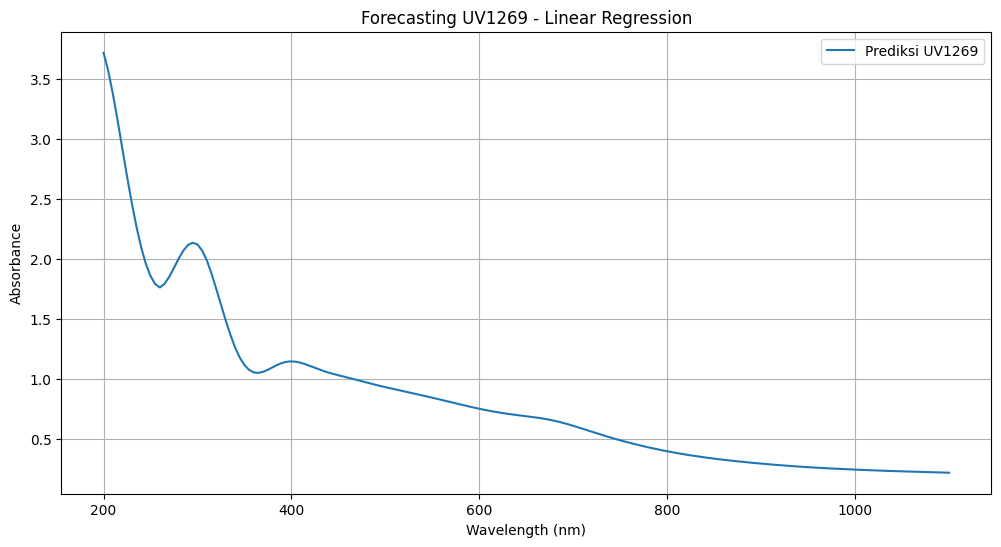

In [17]:
linear3 = LinearRegression()

linear3.fit(
    X3_scaled,
    y3
)

pred_uv1269_linear = linear3.predict(
    X3_scaled
)

plt.figure(figsize=(12,6))

plt.plot(
    wavelength,
    pred_uv1269_linear,
    label='Prediksi UV1269'
)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Absorbance')

plt.title(
    'Forecasting UV1269 - Linear Regression'
)

plt.legend()
plt.grid(True)

plt.show()

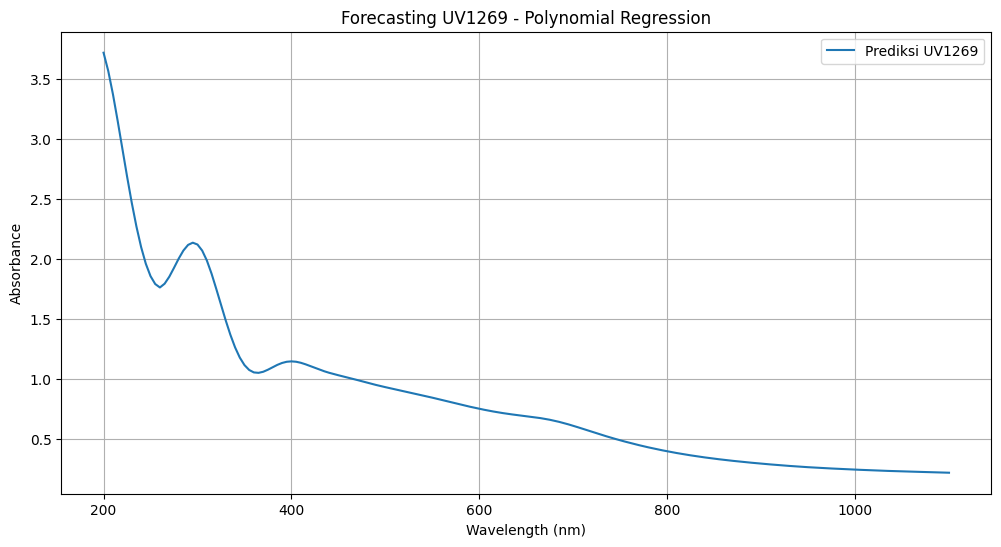

In [18]:
poly3 = Pipeline([

    (
        'poly',
        PolynomialFeatures(
            degree=2,
            include_bias=False
        )
    ),

    (
        'linear',
        LinearRegression()
    )

])

poly3.fit(
    X3_scaled,
    y3
)

pred_uv1269_poly = poly3.predict(
    X3_scaled
)

plt.figure(figsize=(12,6))

plt.plot(
    wavelength,
    pred_uv1269_poly,
    label='Prediksi UV1269'
)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Absorbance')

plt.title(
    'Forecasting UV1269 - Polynomial Regression'
)

plt.legend()
plt.grid(True)

plt.show()

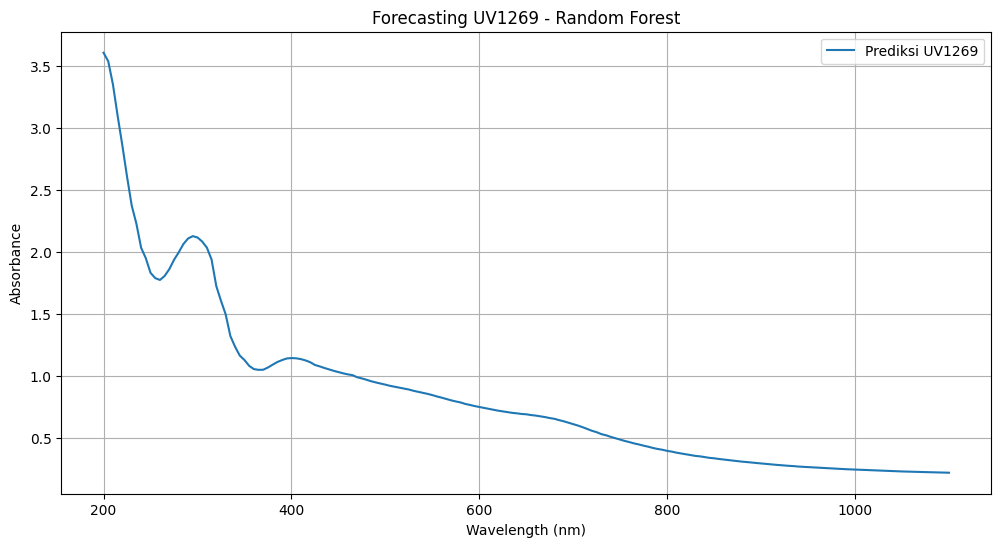

In [19]:
rf3 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf3.fit(
    X3_scaled,
    y3
)

pred_uv1269_rf = rf3.predict(
    X3_scaled
)

plt.figure(figsize=(12,6))

plt.plot(
    wavelength,
    pred_uv1269_rf,
    label='Prediksi UV1269'
)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Absorbance')

plt.title(
    'Forecasting UV1269 - Random Forest'
)

plt.legend()
plt.grid(True)

plt.show()

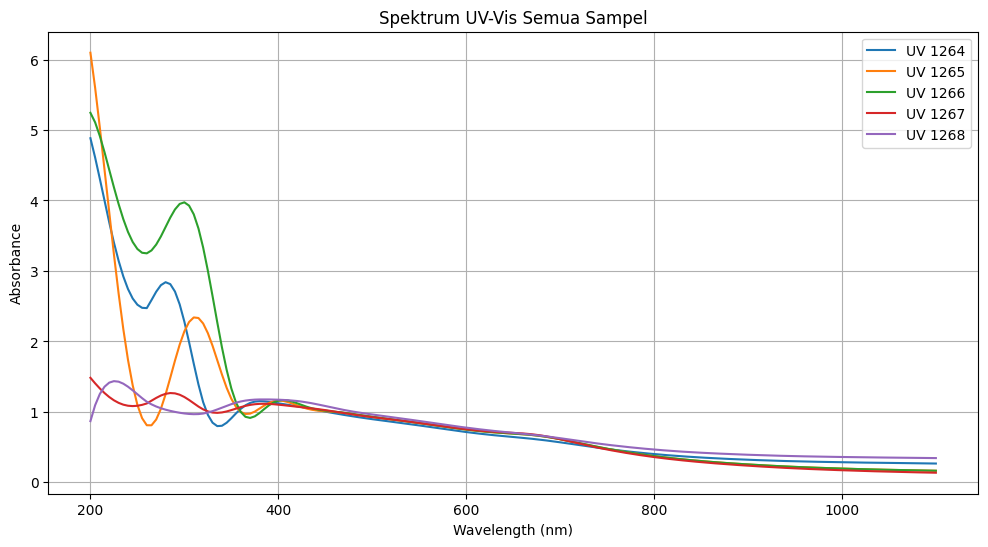

In [9]:
plt.figure(figsize=(12,6))

for i in range(len(df)):
    plt.plot(
        wavelength,
        df.iloc[i,1:].values.astype(float),
        label=df.iloc[i,0]
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance")
plt.title("Spektrum UV-Vis Semua Sampel")
plt.legend()
plt.grid(True)
plt.show()

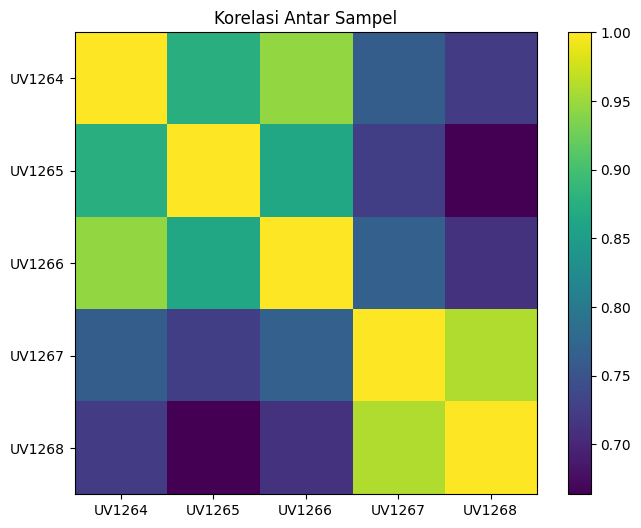

In [10]:
corr_df = pd.DataFrame({
    'UV1264': sample_1264,
    'UV1265': sample_1265,
    'UV1266': sample_1266,
    'UV1267': sample_1267,
    'UV1268': sample_1268
})

corr = corr_df.corr()

plt.figure(figsize=(8,6))

im = plt.imshow(corr)

plt.colorbar(im)

plt.xticks(
    range(len(corr.columns)),
    corr.columns
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title('Korelasi Antar Sampel')

plt.show()

## Kesimpulan Hasil Prediksi Kedua Skenario

1. Secara umum, **Skenario 2** (prediksi 1268 dari 1264, 1265, 1266, 1267) memberikan performa lebih baik daripada **Skenario 1** (prediksi 1267 dari 1264, 1265, 1266), terutama pada model Linear dan Random Forest.

2. Pada **Skenario 1**, model terbaik adalah **Polynomial Regression** dengan rentang nilai **R² = 0.99863 - 0.99928** dan **RMSE = 0.01020 - 0.01445**. Model ini konsisten paling akurat di semua rasio split.

3. Pada **Skenario 2**, model terbaik juga **Polynomial Regression** dengan performa lebih tinggi dan sangat stabil, yaitu **R² = 0.99965 - 0.99972** dan **RMSE = 0.00507 - 0.00598**.

4. Dibandingkan model lain, **Linear Regression** menunjukkan peningkatan besar dari Skenario 1 ke Skenario 2 (R² naik dari sekitar 0.62-0.68 menjadi 0.85-0.92), menandakan tambahan sampel input meningkatkan kemampuan prediksi.

5. **Random Forest** juga membaik pada Skenario 2 (R² sekitar 0.96-0.99) dibanding Skenario 1 (R² sekitar 0.99 tetapi cenderung turun saat split 90:10), namun tetap berada di bawah Polynomial Regression dalam kestabilan error.

6. Dari sisi rasio split, pola terbaik cenderung muncul pada **split 60:40 sampai 80:20**. Split **90:10** menunjukkan kecenderungan penurunan pada beberapa model (terutama Linear dan Random Forest), kemungkinan karena data uji terlalu sedikit sehingga evaluasi kurang representatif.

### Ringkasan Akhir

- **Model paling direkomendasikan:** Polynomial Regression.
- **Skenario paling direkomendasikan:** Skenario 2.
- **Alasan utama:** nilai R² paling mendekati 1 dan RMSE paling kecil serta paling stabil di berbagai split.

In [20]:
hasil_s1_compare.to_csv(
    "hasil_s1_compare.csv",
    index=False
)

hasil_s2_compare.to_csv(
    "hasil_s2_compare.csv",
    index=False
)